<a href="https://colab.research.google.com/github/HARISH-BN890/Lost-and-Found-AI/blob/main/Lost_and_Found_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import torch

print("Python Version:", sys.version.split()[0])
print("PyTorch Version:", torch.__version__)
print("Device Available:", "GPU" if torch.cuda.is_available() else "CPU")

Python Version: 3.13.15
PyTorch Version: 2.11.0+cpu
Device Available: CPU


In [2]:
# Cell 2: Install required AI and UI libraries
!pip install -q transformers gradio pillow

In [3]:
# Cell 3: Verify library imports
import transformers
import gradio as gr
import PIL

print("Transformers Version:", transformers.__version__)
print("Gradio Version:", gr.__version__)
print("PIL (Pillow) Version:", PIL.__version__)
print("All dependencies imported successfully!")

Transformers Version: 5.16.1
Gradio Version: 6.26.0
PIL (Pillow) Version: 11.3.0
All dependencies imported successfully!


In [4]:
# Cell 4: Load the pre-trained Vision Transformer (ViT) model
from transformers import pipeline

MODEL_NAME = "google/vit-base-patch16-224"

print(f"Loading model: {MODEL_NAME}...")
classifier = pipeline("image-classification", model=MODEL_NAME)

# Check how many object classes the model can recognize
num_classes = len(classifier.model.config.id2label)
print("Model loaded successfully!")
print(f"Total recognizable object classes: {num_classes}")

# Print 5 example classes stored inside the model
sample_labels = [classifier.model.config.id2label[i] for i in range(500, 505)]
print("Sample classes:", sample_labels)

Loading model: google/vit-base-patch16-224...


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Model loaded successfully!
Total recognizable object classes: 1000
Sample classes: ['cliff dwelling', 'cloak', 'clog, geta, patten, sabot', 'cocktail shaker', 'coffee mug']


Original Image Size (Width, Height): (400, 600)


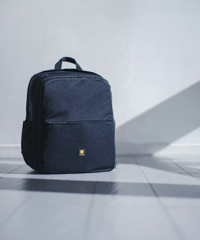


--- Raw Model Output (Top 5) ---
{'label': 'backpack, back pack, knapsack, packsack, rucksack, haversack', 'score': 0.8979666829109192}
{'label': 'mailbag, postbag', 'score': 0.08983756601810455}
{'label': 'purse', 'score': 0.002714464906603098}
{'label': 'sleeping bag', 'score': 0.0007346172351390123}
{'label': 'bulletproof vest', 'score': 0.0005173321114853024}

--- Clean Formatted Result ---
Object     : Backpack
Confidence : 89.8%


In [6]:
# Cell 5: Test the model with a sample image and inspect raw output
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display

# 1. Download a sample backpack image from a direct image host
image_url = "https://images.unsplash.com/photo-1553062407-98eeb64c6a62?w=400"
sample_path = "sample_item.jpg"

response = requests.get(image_url, timeout=10)
with open(sample_path, "wb") as out_file:
    out_file.write(response.content)

# 2. Load the image and convert it to 3-channel RGB
img = Image.open(sample_path).convert("RGB")
print("Original Image Size (Width, Height):", img.size)
display(img.resize((200, 240)))

# 3. Run AI Inference on the image
raw_predictions = classifier(img)

# 4. Print the Top 5 raw predictions returned by the model
print("\n--- Raw Model Output (Top 5) ---")
for pred in raw_predictions:
    print(pred)

# 5. Extract the #1 top prediction and convert score to percentage
top_prediction = raw_predictions[0]
predicted_object = top_prediction["label"].split(",")[0].title()
confidence_percent = round(top_prediction["score"] * 100, 2)

print("\n--- Clean Formatted Result ---")
print(f"Object     : {predicted_object}")
print(f"Confidence : {confidence_percent}%")

In [7]:
# Cell 6: Define Lost & Found Categories and Mapping Function

# Dictionary mapping college Lost & Found categories to ImageNet label keywords
CATEGORY_KEYWORDS = {
    "Electronics": [
        "laptop", "notebook", "computer", "cellular telephone", "cellphone",
        "mobile phone", "ipod", "headphone", "earphone", "earplug", "mouse",
        "keyboard", "modem", "hard disc", "flash drive", "power bank",
        "calculator", "digital watch", "stopwatch", "camera", "reflex camera",
        "joystick", "microphone", " monitor", "remote control", "cassette"
    ],
    "Bags & Wallets": [
        "backpack", "back pack", "knapsack", "rucksack", "mailbag", "postbag",
        "purse", "handbag", "wallet", "billfold", "notecase", "pocketbook",
        "briefcase", "suitcase", "traveling bag", "plastic bag", "pencil box",
        "pencil case", "pouch"
    ],
    "Bottles & Containers": [
        "water bottle", "pop bottle", "soda bottle", "beer bottle", "wine bottle",
        "thermos", "coffee mug", "cup", "beaker", "pitcher", "jug", "water jug",
        "lunchbox", "tiffin", "can", "flask"
    ],
    "Books & Stationery": [
        "book", "book jacket", " dust cover", "binder", "ring-binder",
        "envelope", "ballpoint", "pen", "fountain pen", "quill", "pencil",
        "rubber eraser", "pencil sharpener", "ruler", "scale", "scissors",
        "notebook"
    ],
    "Clothing & Footwear": [
        "running shoe", "shoe", "sneaker", "sandal", "clog", "boot", "loafer",
        "sweatshirt", "jersey", "t-shirt", "tee shirt", "jacket", "coat",
        "cardigan", "sweater", "hoodie", "jean", "sock", "cap", "hat",
        "cowboy hat", "sombrero", "scarf", "stole", "glove", "mitten", "tie"
    ],
    "Personal Accessories": [
        "sunglasses", "dark glasses", "spectacles", "eyeglasses", "watch",
        "analog watch", "umbrella", "key", " padlock", "lock", "chain",
        "necklace", "ring", "bracelet", "hair slide", "comb", "helm",
        "crash helmet", "id card"
    ],
    "Sports & Musical Gear": [
        "basketball", "soccer ball", "tennis ball", "racket", "racquet",
        "cricket", "baseball", "badminton", "dumbbell", "guitar", "flute",
        "violin", "drum"
    ]
}

def map_to_category(raw_label: str) -> str:
    """
    Takes the raw ImageNet label string (e.g., 'backpack, back pack, knapsack')
    and returns the matching College Lost & Found Category.
    """
    label_lower = raw_label.lower()

    for category, keywords in CATEGORY_KEYWORDS.items():
        for keyword in keywords:
            if keyword in label_lower:
                return category

    return "Other / Miscellaneous Campus Item"

# Quick test with 4 sample labels
test_labels = [
    "backpack, back pack, knapsack",
    "water bottle",
    "cellular telephone, cellular phone, cellphone",
    "running shoe"
]

print("--- Category Mapping Test ---")
for lbl in test_labels:
    clean_name = lbl.split(",")[0].title()
    category = map_to_category(lbl)
    print(f"Object: {clean_name:<22} -> Category: {category}")

--- Category Mapping Test ---
Object: Backpack               -> Category: Bags & Wallets
Object: Water Bottle           -> Category: Bottles & Containers
Object: Cellular Telephone     -> Category: Electronics
Object: Running Shoe           -> Category: Clothing & Footwear
